# Opportunities Demo

Demonstrates the `opportunities` function with different parameter values
using real data files.

## Setup

In [1]:
from shelterbelts.indices.opportunities import opportunities, opportunity_cmap, opportunity_labels
from shelterbelts.utils.filepaths import get_filename
from shelterbelts.utils.visualisation import visualise_categories_sidebyside, visualise_categories

tree_file = get_filename('g2_26729_binary_tree_cover_10m.tiff')
roads_file = get_filename('g2_26729_roads.tif')
gullies_file = get_filename('g2_26729_hydrolines.tif')
dem_file = get_filename('g2_26729_DEM-H.tif')
worldcover_file = get_filename('g2_26729_worldcover.tif')

print(f"Tree file: {tree_file}")

common = dict(dem_data=dem_file, worldcover_data=worldcover_file, outdir='/tmp', savetif=False, plot=False)

Tree file: /home/147/cb8590/Projects/shelterbelts/data/g2_26729_binary_tree_cover_10m.tiff


## Default Parameters

In [2]:
ds_default = opportunities(
    tree_file, roads_data=roads_file, gullies_data=gullies_file, **common, stub='demo_default',
)
ds_default

<xarray.Dataset> Size: 84kB
Dimensions:        (x: 201, y: 201)
Coordinates:
  * x              (x) float64 2kB 6.3e+05 6.3e+05 6.3e+05 ... 6.32e+05 6.32e+05
  * y              (y) float64 2kB 6.196e+06 6.196e+06 ... 6.194e+06 6.194e+06
    spatial_ref    int64 8B 0
Data variables:
    woody_veg      (y, x) uint8 40kB 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0 0
    opportunities  (y, x) uint8 40kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0

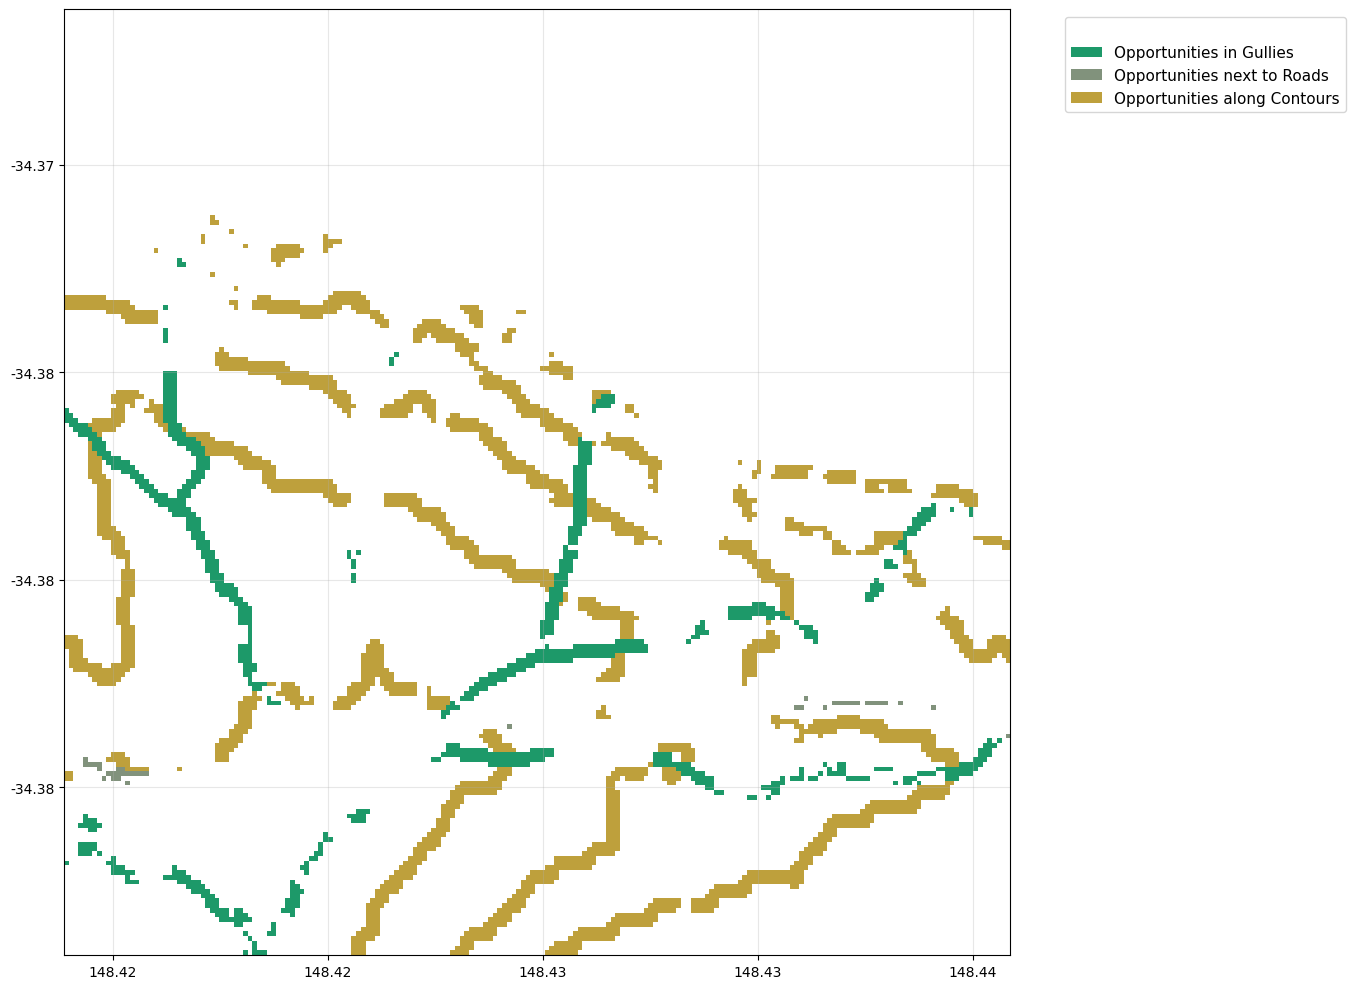

In [3]:
visualise_categories(
    ds_default['opportunities'],
    colormap=opportunity_cmap,
    labels=opportunity_labels
)

## Just roads vs just gullies

Showing the effect of each feature in isolation by zeroing out the other.

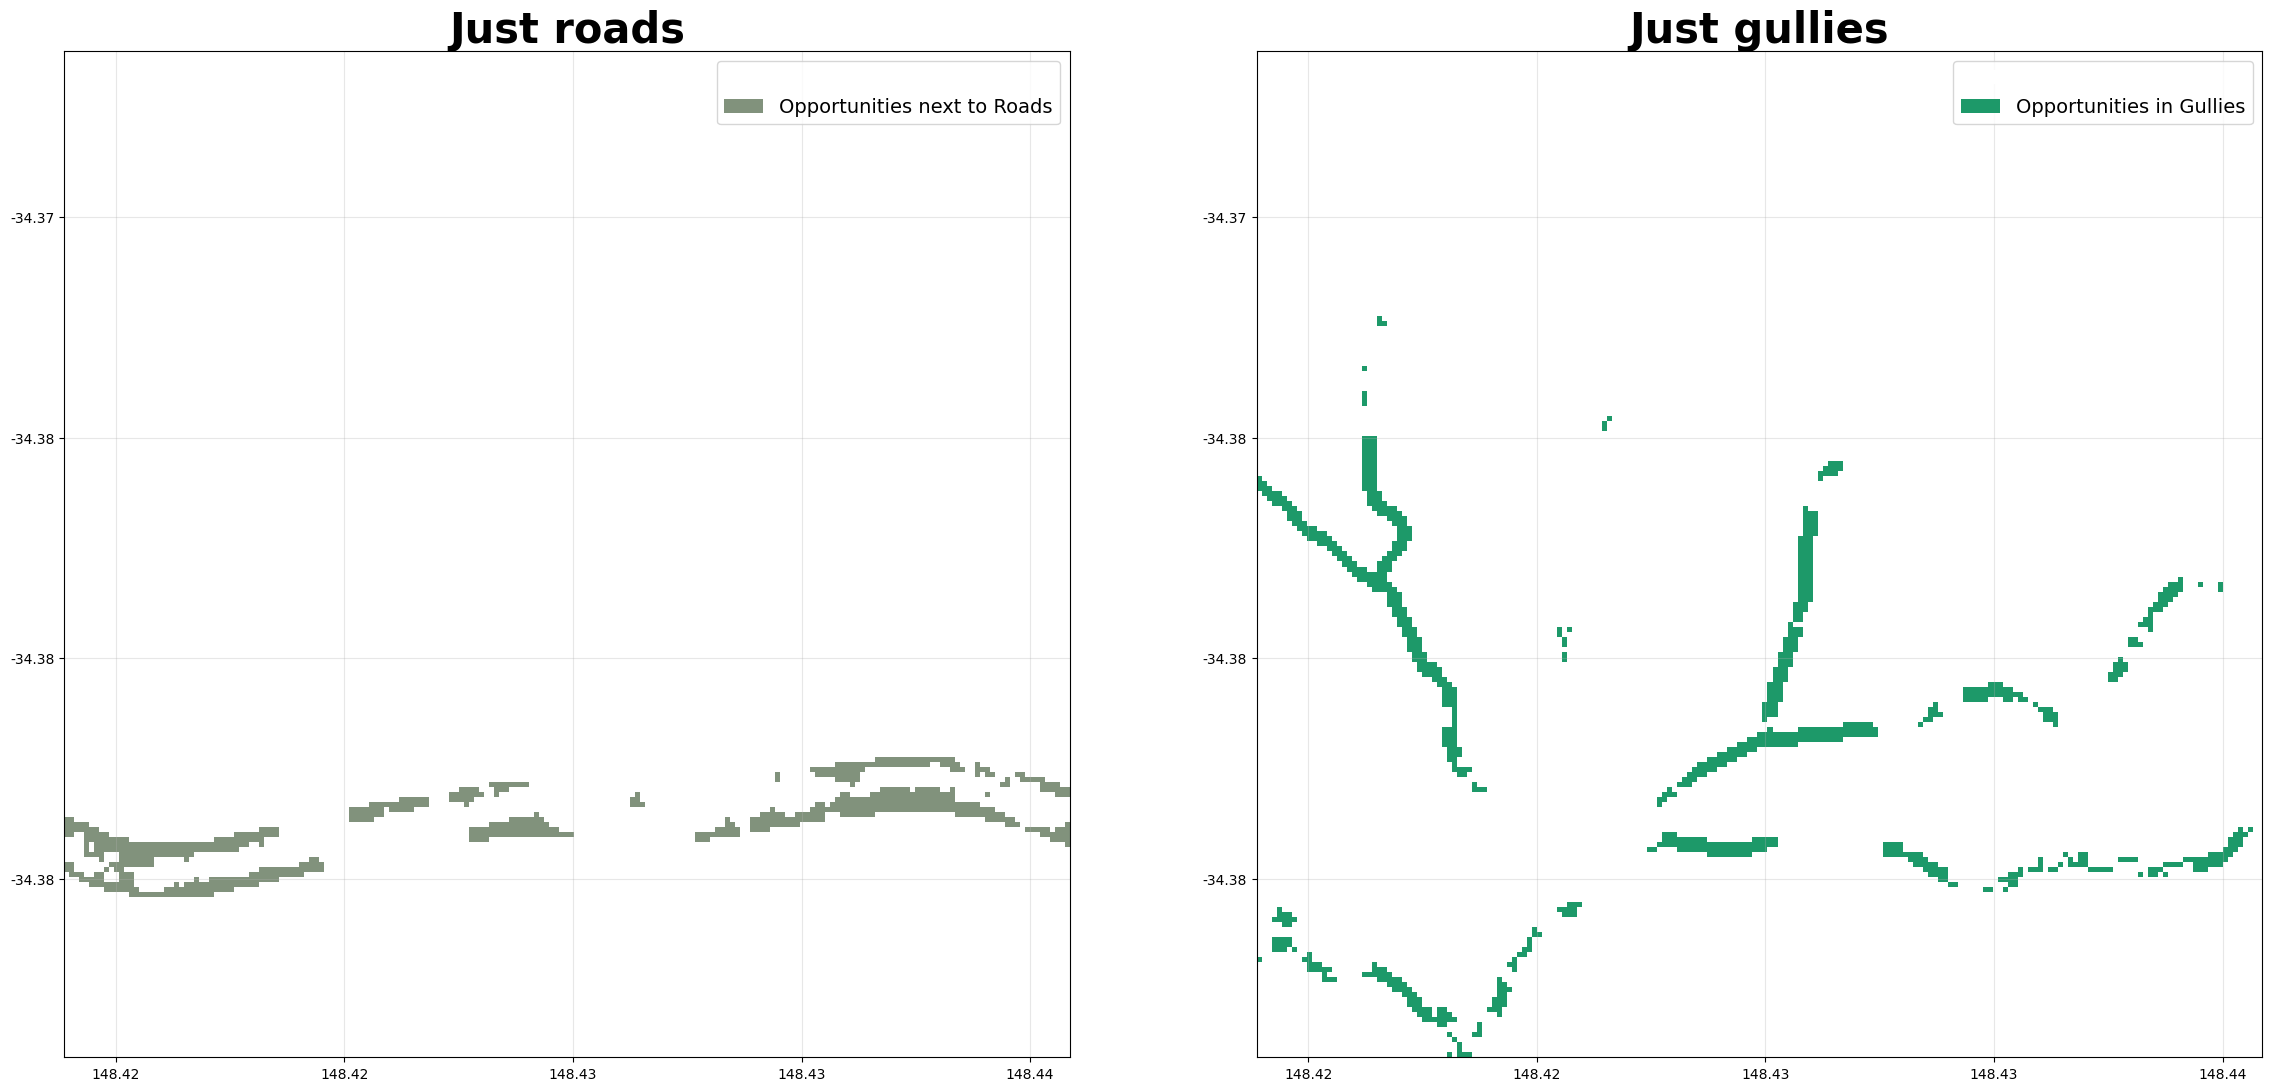

In [4]:
import rioxarray as rxr
da_zero = rxr.open_rasterio(roads_file).isel(band=0).drop_vars('band') * 0

ds_roads = opportunities(tree_file, roads_data=roads_file, gullies_data=da_zero, **common, stub='demo_roads', contour_spacing=0, width=5)
ds_gullies = opportunities(tree_file, roads_data=da_zero, gullies_data=gullies_file, **common, stub='demo_gullies', contour_spacing=0)

visualise_categories_sidebyside(
    ds_roads['opportunities'], ds_gullies['opportunities'],
    colormap=opportunity_cmap, labels=opportunity_labels,
    title1="Just roads", title2="Just gullies"
)

## Changing the width

The `width` parameter controls how many pixels away from each feature still
count as within the buffer for planting opportunities.

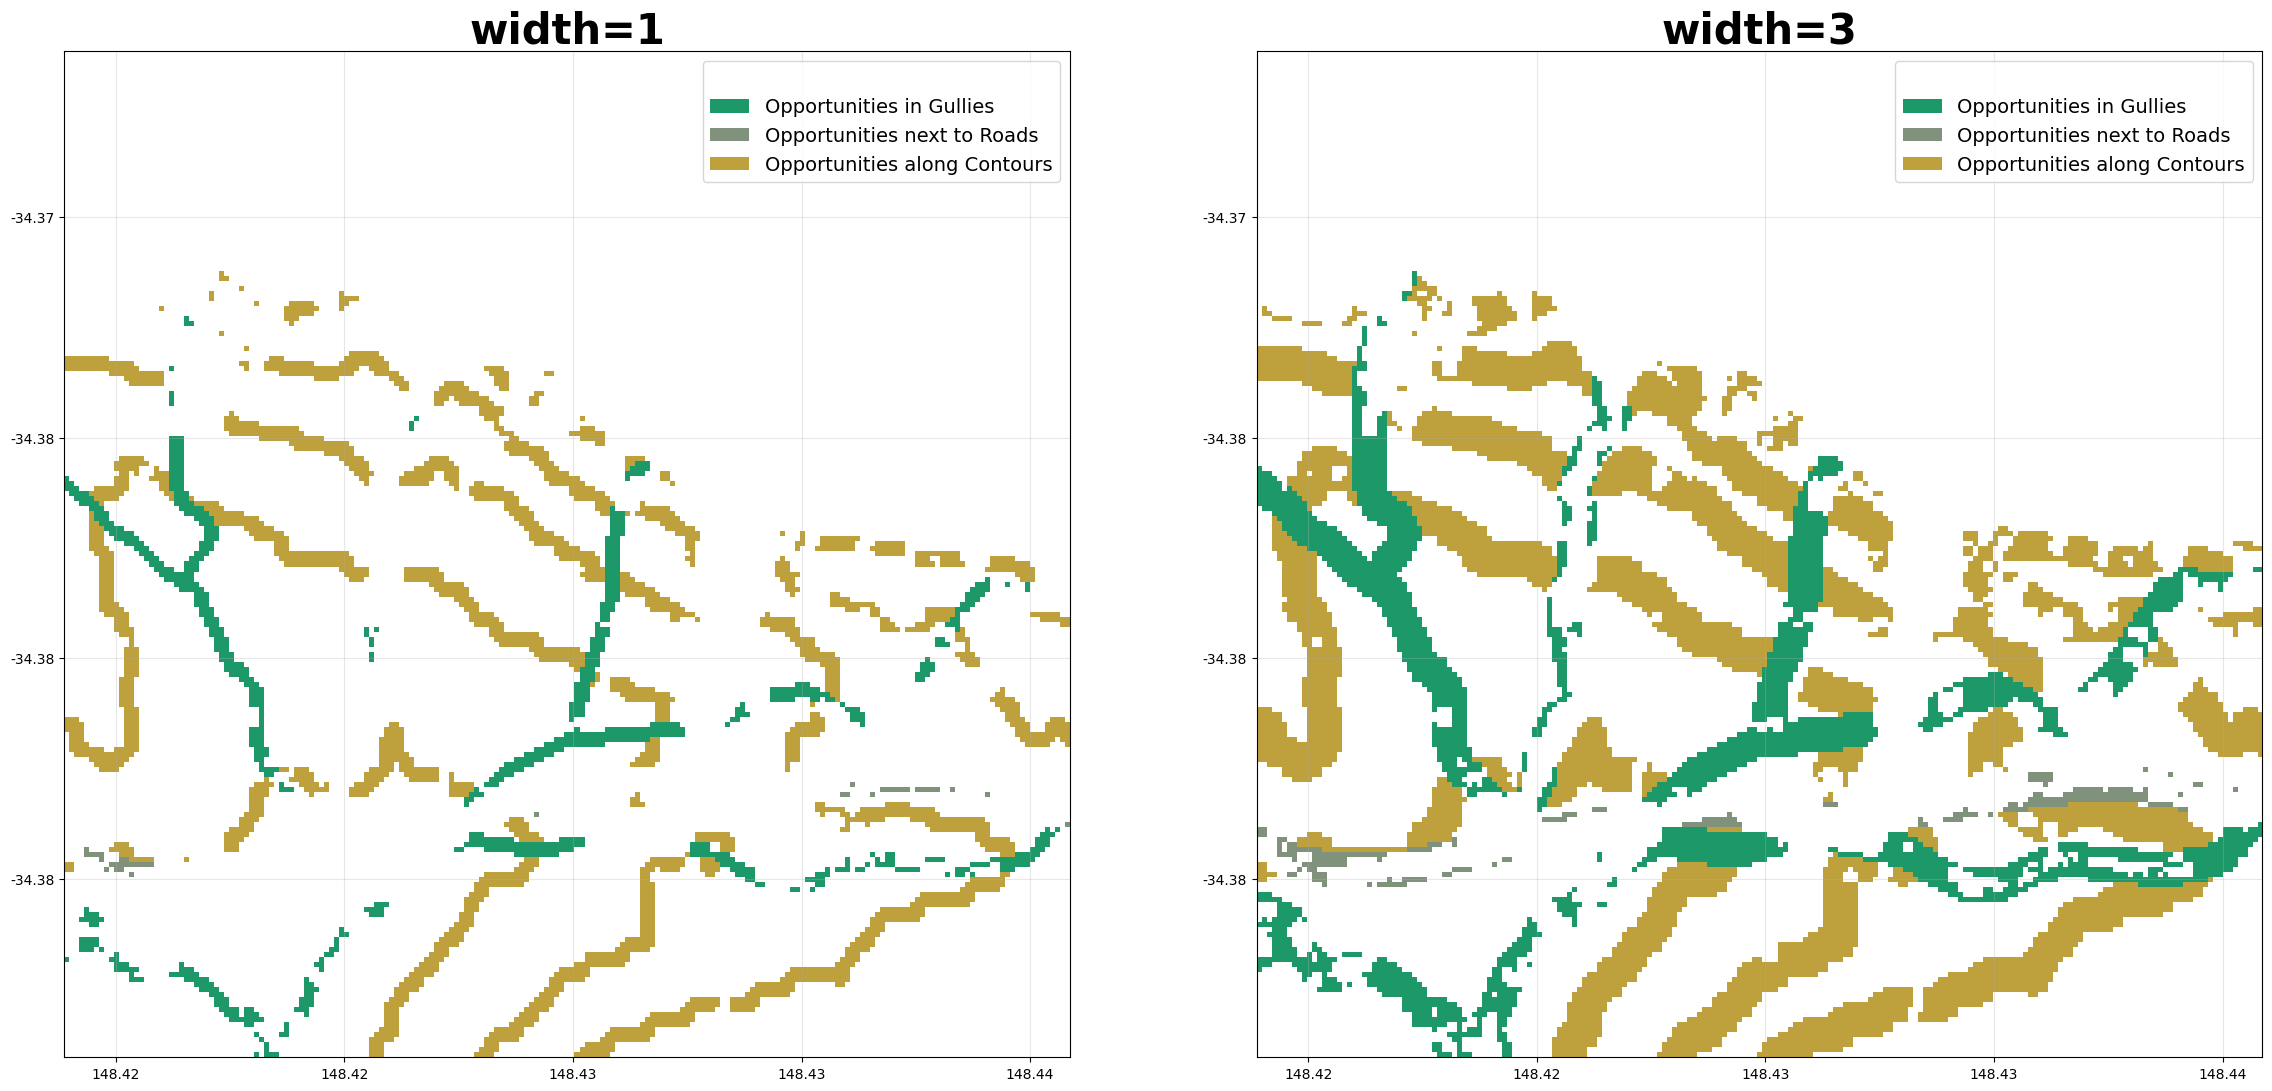

In [5]:
ds_w1 = opportunities(
    tree_file, roads_data=roads_file, gullies_data=gullies_file, **common, stub='demo_w1', width=1,
)
ds_w5 = opportunities(
    tree_file, roads_data=roads_file, gullies_data=gullies_file, **common, stub='demo_w3', width=3,
)

visualise_categories_sidebyside(
    ds_w1['opportunities'], ds_w5['opportunities'],
    colormap=opportunity_cmap, labels=opportunity_labels,
    title1="width=1", title2="width=3"
)

## Changing the contour spacing

The `contour_spacing` parameter controls the number of pixels between each
contour line. Smaller values produce more contour opportunities.

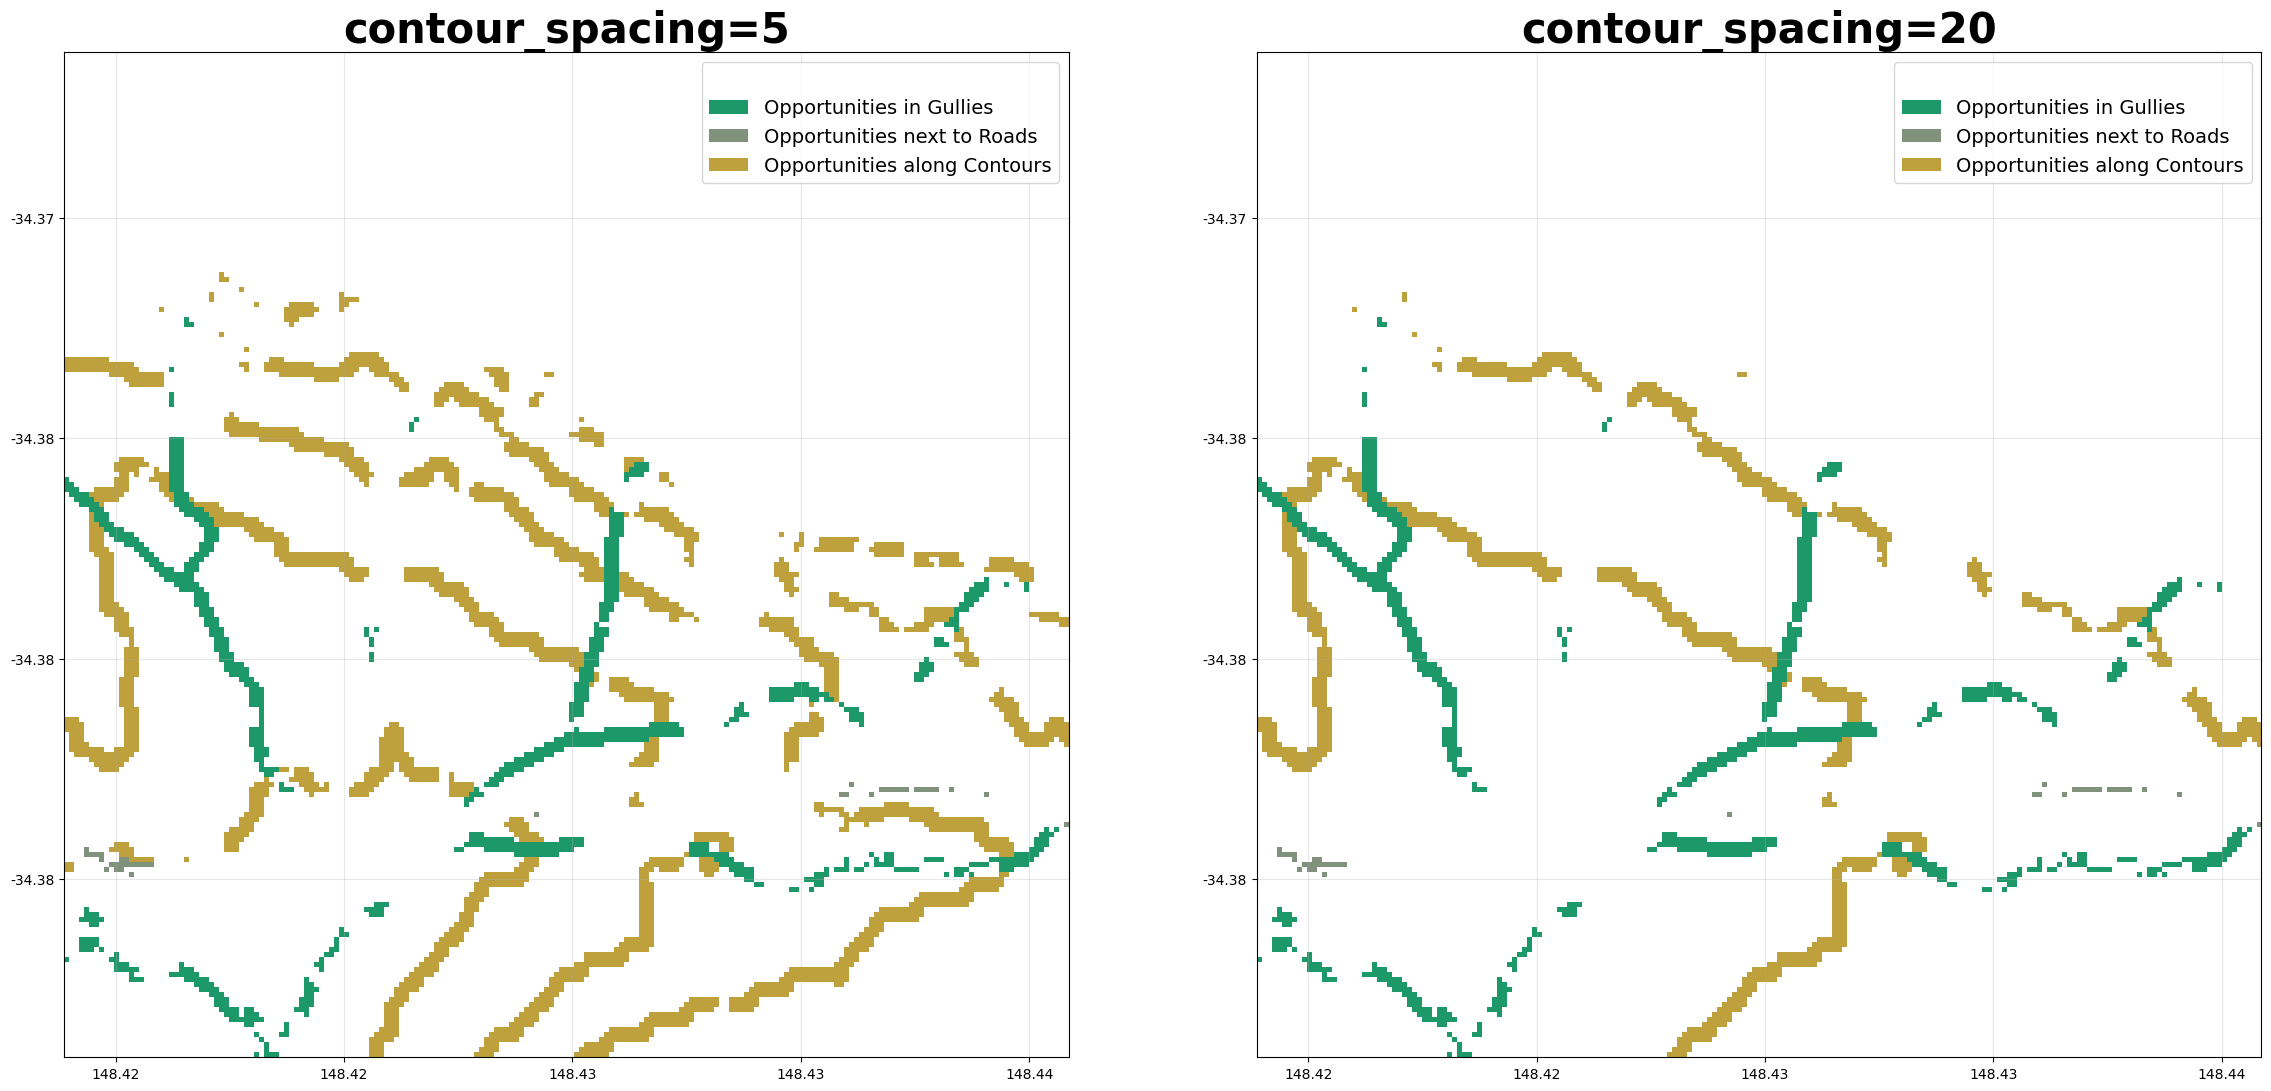

In [6]:
ds_cs5 = opportunities(
    tree_file, roads_data=roads_file, gullies_data=gullies_file, **common, stub='demo_cs5', contour_spacing=10,
)
ds_cs20 = opportunities(
    tree_file, roads_data=roads_file, gullies_data=gullies_file, **common, stub='demo_cs20', contour_spacing=20,
)

visualise_categories_sidebyside(
    ds_cs5['opportunities'], ds_cs20['opportunities'],
    colormap=opportunity_cmap, labels=opportunity_labels,
    title1="contour_spacing=5", title2="contour_spacing=20"
)

## Command Line Interface
You can also use the function from the command line with the same defaults and parameters.

In [7]:
!python -m shelterbelts.indices.opportunities --help

usage: opportunities.py [-h] [--outdir OUTDIR] [--stub STUB] [--tmpdir TMPDIR]
                        [--cover_threshold COVER_THRESHOLD] [--width WIDTH]
                        [--ridges] [--num_catchments NUM_CATCHMENTS]
                        [--min_branch_length MIN_BRANCH_LENGTH]
                        [--contour_spacing CONTOUR_SPACING]
                        [--min_contour_length MIN_CONTOUR_LENGTH]
                        [--equal_area] [--no-savetif] [--plot]
                        [--crop_pixels CROP_PIXELS] [--limit LIMIT]
                        percent_tif

Suggest opportunities for new trees based on ridges, gullies, and contours.

positional arguments:
  percent_tif           Input percentage cover tree tif file

options:
  -h, --help            show this help message and exit
  --outdir OUTDIR       Output directory for saving results (default: current
                        directory)
  --stub STUB           Prefix for output filenames (default: derived from
    